# Bayesian Model Comparison: WAIC and LOO-CV

## Overview

Bayesian model comparison evaluates models by their **expected log predictive density (ELPD)** — how well a model predicts new data it has not seen. Two estimators of ELPD:

| Method | Full name | Key property |
|---|---|---|
| **LOO-CV** | Leave-one-out cross-validation | Approximate via PSIS-LOO; gold standard |
| **WAIC** | Widely Applicable (Watanabe-Akaike) IC | Asymptotically equivalent to LOO; less stable in tails |

Both are computed from the **log-likelihood of each observation** averaged over the posterior — they do not require refitting the model.

**Key quantities:**
- **ELPD_loo**: expected log predictive density; higher is better
- **LOOIC** = −2 × ELPD_loo; lower is better (analogous to AIC scale)
- **ELPD difference (Δ ELPD)**: how much better one model is than another
- **SE of Δ ELPD**: uncertainty in the comparison
- **p_loo**: effective number of parameters; much larger than actual → model is overfit or misspecified

**Rule of thumb:** A difference of |Δ ELPD| / SE > 2 indicates a meaningful difference between models.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(brms)
library(loo)         # loo(), waic(), loo_compare()
library(tidybayes)

set.seed(42)

# ── Simulate data: true relationship is linear ────────────────────────────────
n <- 150
comp_data <- tibble(
  habitat   = factor(rep(c("reference","restored","degraded"), each=n/3),
                     levels=c("reference","restored","degraded")),
  nitrate   = rnorm(n, 3, 1),
  richness  = pmax(round(
    25 +
    case_when(habitat=="reference"~0, habitat=="restored"~-3, habitat=="degraded"~-8) +
    -2 * nitrate +
    rnorm(n, 0, 3)
  ), 1)
)

# ── Fit four candidate models ─────────────────────────────────────────────────
fit_args <- list(data=comp_data, chains=4, iter=3000,
                 warmup=1000, cores=4, seed=42, silent=2)

# M1: intercept only
m1 <- do.call(brm, c(list(
  formula = richness ~ 1,
  prior   = c(prior(normal(20,10), class=Intercept),
              prior(exponential(1), class=sigma))
), fit_args))

# M2: nitrate only
m2 <- do.call(brm, c(list(
  formula = richness ~ nitrate,
  prior   = c(prior(normal(20,10), class=Intercept),
              prior(normal(0,3),   class=b),
              prior(exponential(1), class=sigma))
), fit_args))

# M3: nitrate + habitat
m3 <- do.call(brm, c(list(
  formula = richness ~ nitrate + habitat,
  prior   = c(prior(normal(20,10), class=Intercept),
              prior(normal(0,3),   class=b),
              prior(exponential(1), class=sigma))
), fit_args))

# M4: nitrate * habitat interaction
m4 <- do.call(brm, c(list(
  formula = richness ~ nitrate * habitat,
  prior   = c(prior(normal(20,10), class=Intercept),
              prior(normal(0,3),   class=b),
              prior(exponential(1), class=sigma))
), fit_args))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'brms' was built under R version 4.4.3"
Loading required package: Rcpp

Loading 'brms' package (version 2.2

---

## LOO-CV: Leave-One-Out Cross-Validation


Computed from 8000 by 150 log-likelihood matrix.

         Estimate   SE
elpd_loo   -378.3  8.3
p_loo         4.6  0.5
looic       756.7 16.6
------
MCSE of elpd_loo is 0.0.
MCSE and ESS estimates assume MCMC draws (r_eff in [0.9, 1.3]).

All Pareto k estimates are good (k < 0.7).
See help('pareto-k-diagnostic') for details.


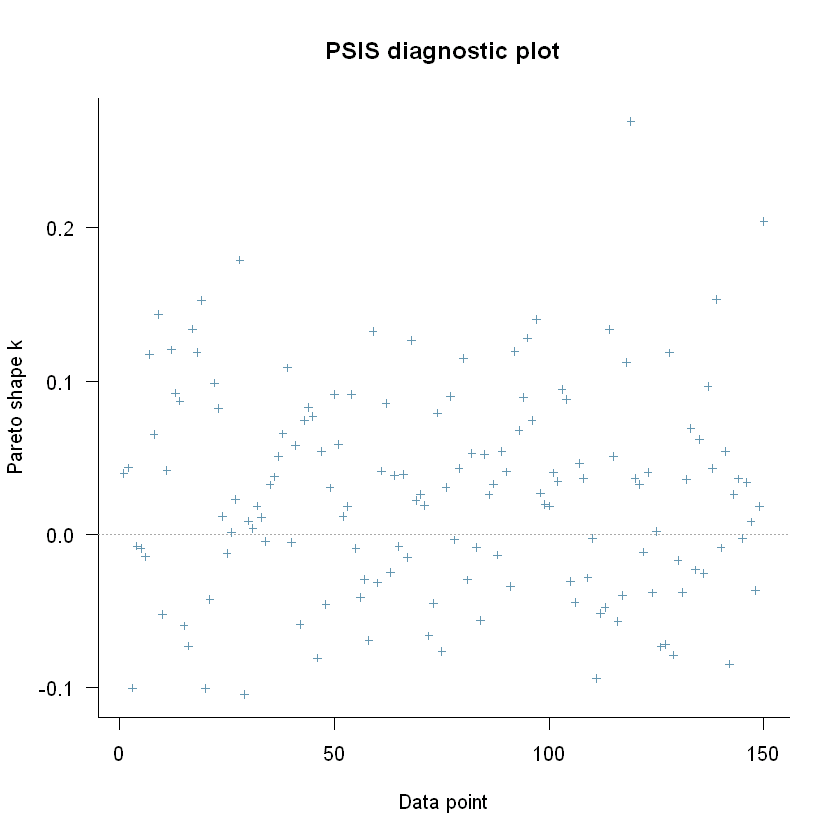

In [2]:
# Add LOO criterion to each model (computed from posterior log-likelihoods)
m1 <- add_criterion(m1, "loo")
m2 <- add_criterion(m2, "loo")
m3 <- add_criterion(m3, "loo")
m4 <- add_criterion(m4, "loo")

# Inspect LOO for the best candidate
print(m3$criteria$loo)
# Key output:
#   elpd_loo:  ELPD estimate; more positive = better
#   p_loo:     effective number of parameters
#   looic:     -2 * elpd_loo; lower = better
#   Monte Carlo SE: sampling uncertainty in the LOO estimate
#
# Pareto k values:
#   k < 0.5:  good (reliable PSIS approximation)
#   k in 0.5–0.7: OK
#   k > 0.7:  bad — observation is highly influential; refits needed

# ── Pareto k diagnostics ─────────────────────────────────────────────────────
plot(m3$criteria$loo, diagnostic="k", label_points=TRUE)
# High-k observations are overly influential (outliers or model misspecification)

---

## Model Comparison

In [3]:
# Compare all four models
comp <- loo_compare(m1, m2, m3, m4)
print(comp, simplify=FALSE)
# Models ranked by ELPD (best first)
# elpd_diff: how much worse each model is than the best
# se_diff:   SE of the difference
# Models within 2 SE of the best are plausible alternatives

# ── Formatted comparison table ────────────────────────────────────────────────
comp_tidy <- as.data.frame(comp) %>%
  rownames_to_column("model") %>%
  mutate(
    z_score   = round(elpd_diff / se_diff, 2),
    looic     = round(-2 * elpd_loo, 1),
    delta_looic = round(-2 * elpd_diff, 1)
  ) %>%
  select(model, elpd_loo, se_elpd_loo, elpd_diff, se_diff, z_score, p_loo, looic)
print(comp_tidy)

# ── Interpretation ────────────────────────────────────────────────────────────
cat("\nKey rule: |elpd_diff| / se_diff > 2 → meaningful difference\n")
cat("p_loo >> k (params): possible overfitting or misspecification\n")

   elpd_diff se_diff elpd_loo se_elpd_loo p_loo  se_p_loo looic  se_looic
m3    0.0       0.0  -378.3      8.3         4.6    0.5    756.7   16.6  
m4   -1.9       1.2  -380.2      8.4         5.7    0.7    760.5   16.8  
m2  -59.7       7.9  -438.1      7.7         2.9    0.4    876.1   15.4  
m1  -67.5       9.2  -445.9      7.7         1.8    0.2    891.7   15.4  
  model  elpd_loo se_elpd_loo elpd_diff  se_diff z_score    p_loo looic
1    m3 -378.3445    8.312402   0.00000 0.000000     NaN 4.583335 756.7
2    m4 -380.2313    8.393941  -1.88680 1.225357   -1.54 5.746477 760.5
3    m2 -438.0545    7.722577 -59.71007 7.905457   -7.55 2.894174 876.1
4    m1 -445.8604    7.693656 -67.51590 9.179624   -7.35 1.815979 891.7

Key rule: |elpd_diff| / se_diff > 2 → meaningful difference
p_loo >> k (params): possible overfitting or misspecification


---

## WAIC

In [4]:
# WAIC: an alternative information criterion on the log-score scale
# Generally prefer LOO for Bayesian models (more stable in the tails)
# WAIC is equivalent to LOO asymptotically but differs in small samples

m3 <- add_criterion(m3, "waic")
m4 <- add_criterion(m4, "waic")
print(m3$criteria$waic)

# ── LOO vs. WAIC: compare estimates ──────────────────────────────────────────
tibble(
  criterion  = c("ELPD (LOO)","ELPD (WAIC)"),
  m3_elpd    = c(m3$criteria$loo$estimates["elpd_loo","Estimate"],
                 m3$criteria$waic$estimates["elpd_waic","Estimate"]),
  m4_elpd    = c(m4$criteria$loo$estimates["elpd_loo","Estimate"],
                 m4$criteria$waic$estimates["elpd_waic","Estimate"])
) %>%
  mutate(
    diff = round(m3_elpd - m4_elpd, 2),
    across(where(is.numeric), ~round(.x, 2))
  ) %>% print()
# LOO and WAIC should agree when models are well-specified
# Large discrepancy signals problematic observations (check Pareto k)

Warning message:
"
1 (0.7%) p_waic estimates greater than 0.4. We recommend trying loo instead."



Computed from 8000 by 150 log-likelihood matrix.

          Estimate   SE
elpd_waic   -378.3  8.3
p_waic         4.6  0.5
waic         756.7 16.6
# A tibble: 2 × 4
  criterion   m3_elpd m4_elpd  diff
  <chr>         <dbl>   <dbl> <dbl>
1 ELPD (LOO)    -378.   -380.  1.89
2 ELPD (WAIC)   -378.   -380.  1.88


---

## Visualising Model Comparison

Warning message:
"The `fatten` argument of `geom_pointrange()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `size` aesthetic instead."


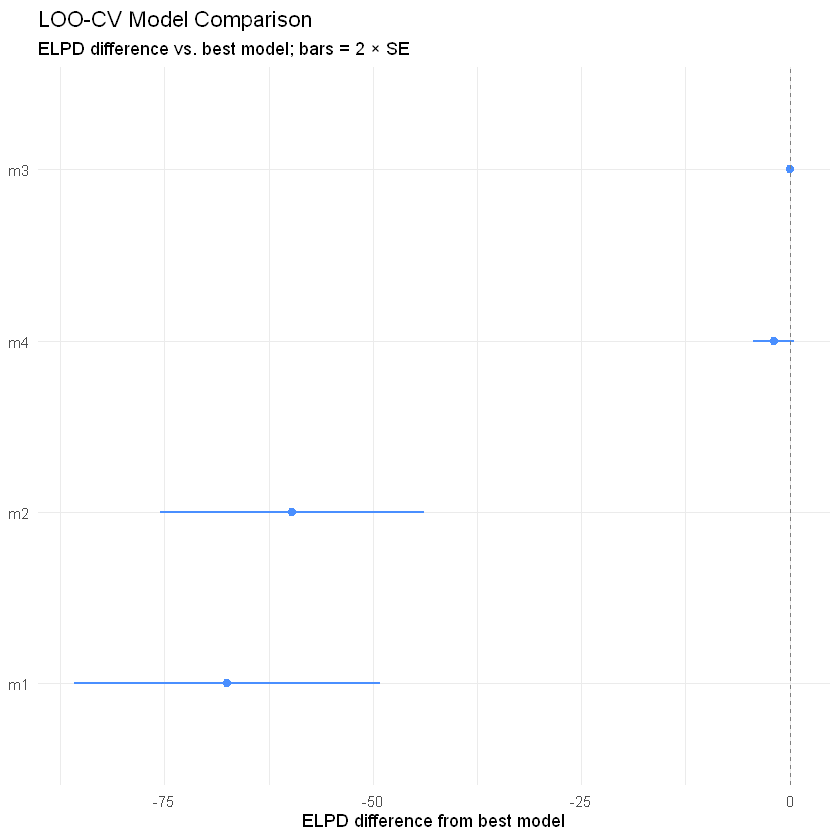

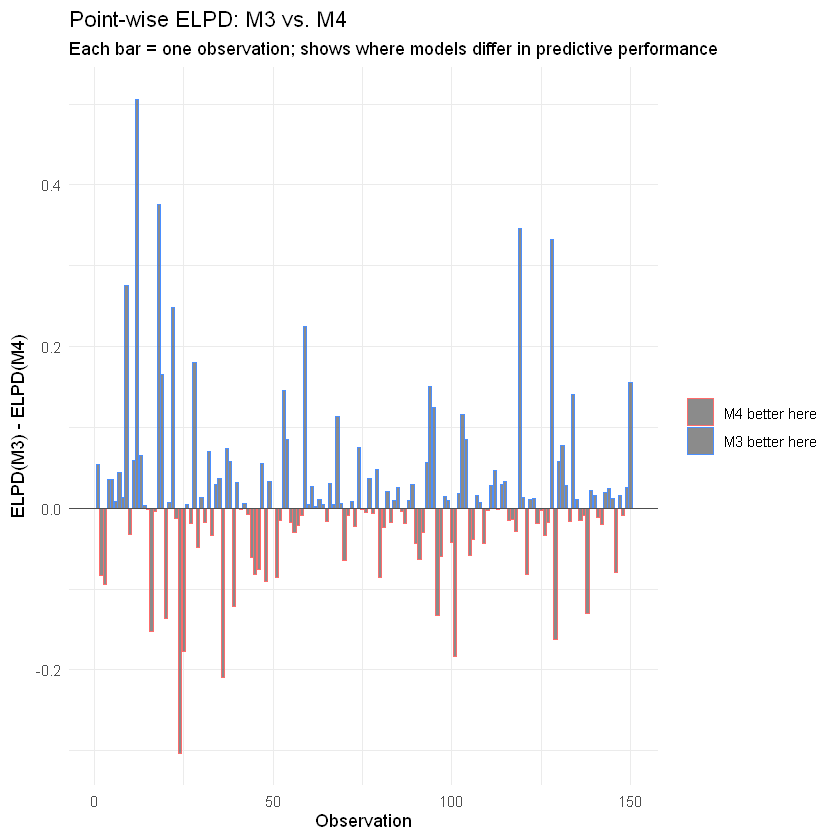

In [5]:
# ELPD comparison plot
comp_df <- as.data.frame(comp) %>%
  rownames_to_column("model") %>%
  mutate(model=factor(model, levels=rev(rownames(comp))))

ggplot(comp_df, aes(x=elpd_diff, xmin=elpd_diff - 2*se_diff,
                    xmax=elpd_diff + 2*se_diff, y=model)) +
  geom_pointrange(color="#4a8fff", linewidth=0.8, fatten=3) +
  geom_vline(xintercept=0, linetype="dashed", color="gray50") +
  labs(title="LOO-CV Model Comparison",
       subtitle="ELPD difference vs. best model; bars = 2 × SE",
       x="ELPD difference from best model", y=NULL) +
  theme_minimal()

# ── Point-wise LOO contributions ─────────────────────────────────────────────
# Which observations drive the model comparison?
pw_loo_m3 <- m3$criteria$loo$pointwise[,"elpd_loo"]
pw_loo_m4 <- m4$criteria$loo$pointwise[,"elpd_loo"]
pw_diff   <- pw_loo_m3 - pw_loo_m4

tibble(obs=1:n, diff=pw_diff, nitrate=comp_data$nitrate) %>%
  ggplot(aes(x=obs, y=diff,
             color=diff > 0)) +
  geom_col(alpha=0.7) +
  scale_color_manual(values=c("TRUE"="#4a8fff","FALSE"="#ff6b6b"),
                     labels=c("M4 better here","M3 better here")) +
  geom_hline(yintercept=0, color="gray30") +
  labs(title="Point-wise ELPD: M3 vs. M4",
       subtitle="Each bar = one observation; shows where models differ in predictive performance",
       x="Observation", y="ELPD(M3) - ELPD(M4)", color=NULL) +
  theme_minimal()

---

## Common Pitfalls

**1. Selecting the best model by LOO then acting as if it were known to be true**  
LOO ranks models by predictive performance — it does not validate any model as the correct data-generating process. When models are within 2 SE of each other, the comparison is inconclusive and model averaging should be considered.

**2. Ignoring Pareto k > 0.7 warnings**  
High Pareto k values indicate that the LOO approximation is unreliable for specific observations — those observations are highly influential and the model struggles to predict them. This signals either outliers or model misspecification. Do not proceed without investigating.

**3. Using p_loo as a model complexity penalty like AIC's k**  
p_loo is the effective number of parameters, not the actual parameter count. p_loo >> actual parameters usually indicates overfitting or a misspecified model. p_loo < actual parameters (possible in hierarchical models with strong pooling) is fine.

**4. Comparing models with different likelihoods using LOOIC**  
Like AIC, LOOIC values are only comparable across models with the same response variable and the same likelihood family. You cannot compare a Gaussian model with a Poisson model using LOOIC — they are on different log-likelihood scales.

**5. Reporting WAIC when LOO is available**  
WAIC is less stable than PSIS-LOO in the tails of the predictive distribution, and `brms` computes LOO efficiently. Use WAIC only when LOO is computationally intractable (very large datasets with exact LOO).

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*